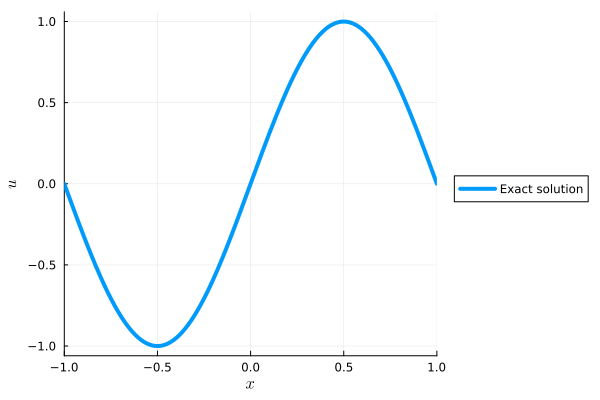

In [1]:
using Polynomials, LinearAlgebra, LaTeXStrings, Plots, Plots.Measures

f(x) = π^2 * sin(π * x)
u_exact(x) = sin(π * x)
plot(
    u_exact,
    xlims = (-1, 1),
    label = "Exact solution",
    linewidth = 4,
    legend = :outerright,
    xlabel = L"x",
    ylabel = L"u",
)

# Colocation system

To solve 
$$
\begin{dcases}
    -\frac{\partial^2 u}{\partial x^2} = f(x_i), \quad \forall i = 1, \cdots, N - 1 \\
    u(-1) = u(1) = 0
\end{dcases}
$$
We look for $u(x) = \sum_{j=0}^N u_j \phi_j(x)$.
The colocation method consists in taking $x_0 = -1, \cdots, x_N = 1$ and solving
$$
\begin{dcases}
    \sum_{j=0}^N \phi_j (x_0) u_j = 0 \\
    -\sum_{j=0}^N \frac{\partial^2 \phi_j}{\partial x^2} (x_i) u_j = f(x_i), \quad \forall i = 1, \cdots, N - 1 \\
    \sum_{j=0}^N \phi_j (x_N) u_j = 0
\end{dcases}
$$
We write the solver using `Polynomials.jl` recalling `julia` indexes from $1$

In [ ]:
function colocation(x::Vector{Float64}, ϕ::Vector{T})::T where T <: AbstractPolynomial
    N = length(x) - 1
    A = zeros(N + 1, N + 1)

    # Dirichlet conditions
    for j = 1:N+1
        A[1, j] = ϕ[j](x[1])
        A[N+1, j] = ϕ[j](x[N+1])
    end 
    # Interior equations
    for i = 2:N, j = 1:N+1
        A[i, j] = -derivative(ϕ[j],2)(x[i])
    end

    b = [0.0; [f(x[j]) for j = 2:N]; 0.0]
    U = A \ b
    return sum(U .* ϕ)
end

colocation (generic function with 1 method)

## Equi-spaced points

In [3]:
N = 3
x = [-1 + 2*j / N for j = 0:N]


4-element Vector{Float64}:
 -1.0
 -0.33333333333333337
  0.33333333333333326
  1.0

## Using monomials as basis

In [4]:
Id = one(zeros(N + 1, N + 1))
monomials = [Polynomial(Id[i, :]) for i = 1:N+1]

4-element Vector{Polynomial{Float64, :x}}:
 Polynomial(1.0)
 Polynomial(1.0*x)
 Polynomial(1.0*x^2)
 Polynomial(1.0*x^3)

Let us solve the algebraic system

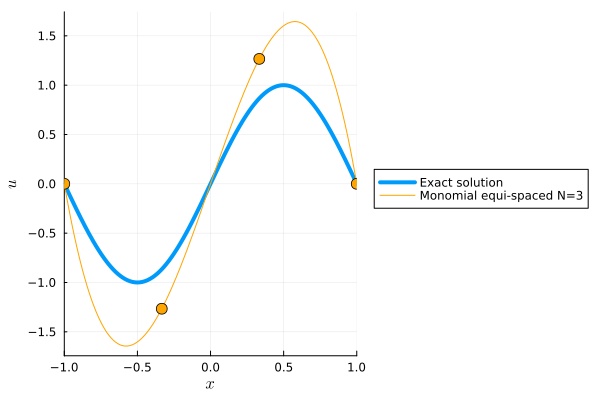

In [5]:
uN = colocation(x, monomials)
color = :orange
plot!(uN, xlims=(-1,1), color=color, label="Monomial equi-spaced N=$N")
scatter!(x, uN.(x), color=color, label="", markersize=6)

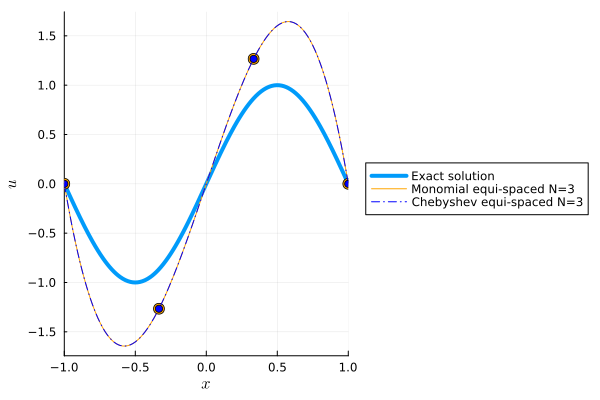

In [6]:
Id = one(zeros(N + 1, N + 1))
T = [ChebyshevT(Id[i, :]) for i = 1:N+1]
uN = colocation(x, T)
color = :blue
plot!(uN, xlims=(-1,1), color=color, label="Chebyshev equi-spaced N=$N", linestyle=:dashdot)
scatter!(x, uN.(x), color=color, label="")

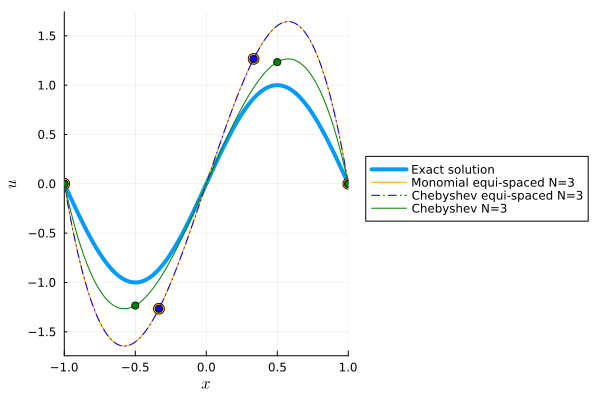

In [7]:
x = [cos(j * π / N) for j = 0:N]
Id = one(zeros(N + 1, N + 1))
T = [ChebyshevT(Id[i, :]) for i = 1:N+1]
uN = colocation(x, T)
color = :green
plot!(uN, xlims=(-1,1), color=color, label="Chebyshev N=$N")
scatter!(x, uN.(x), color=color, label="")

# Convergence graph with Chebyshev points

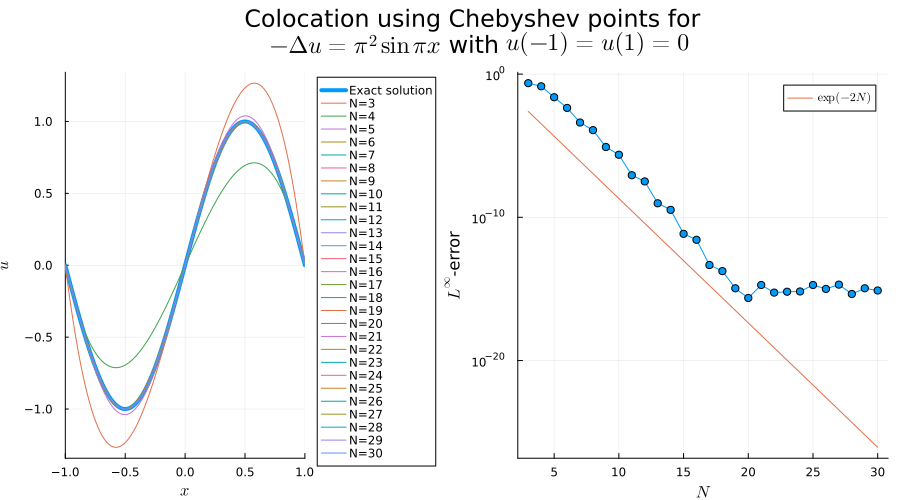

In [8]:
plot(
    u_exact,
    xlims = (-1, 1),
    label = "Exact solution",
    linewidth = 4,
    legend = :outerright,
    xlabel = L"x",
    ylabel = L"u",
)

M = 30
Id = one(zeros(M + 1, M + 1))

Ns = 3:1:M
errors = zeros(length(Ns))

xs = -1.0:1e-10:1.0

for (i, N) in enumerate(Ns)
    x = [cos(j * π / N) for j = 0:N]
    T = [ChebyshevT(Id[i, :]) for i = 1:N+1]
    u = colocation(x, T)

    errors[i] = maximum(abs.(u.(x) - u_exact.(x)))

    plot!(u, xlims = (-1, 1), label = "N=$N")
end
p1 = plot!()

p2 = plot(yscale = :log10, xlabel = L"N", ylabel = L"$L^∞$-error")
plot!(p2,Ns, errors, marker=:circle, label="")
plot!(p2,Ns, exp.(-2*Ns), label=L"\exp(-2N)")

plot(
    p1,
    p2,
    layout = (1, 2),
    size = (900, 500),
    plot_title = latexstring("Colocation using Chebyshev points for \n \$-\\Delta u = \\pi^2 \\sin \\pi x\$ with \$u(-1) = u(1) = 0\$"),
    top_margin=10mm,
)


In [9]:
savefig("convergenceChebyshev.pdf")

"/Users/david/Overleaf/master-mnu/lectures/spectral/intro/convergenceChebyshev.pdf"